# Classificação de Crises Epilépticas via EEG
## Projeto de Otimização Não Linear — Regressão Logística + Gradiente Descendente

**Integrantes:** Bruno Marques Rodrigues, Gabrielly Silva Batista, Josué Caleb Avelino dos Santos, Vitória Emanuele de Sousa Silva.

Este notebook implementa, de forma comentada, um problema de **otimização não linear sem restrições** aplicado ao **aprendizado supervisionado**, mais especificamente uma **classificação binária** de sinais de EEG em duas classes:

- **Classe 1:** crise epiléptica
- **Classe 0:** ausência de crise

A ideia central é modelar a tarefa por meio da **Regressão Logística**, cuja função objetivo é a **Entropia Cruzada (Log-Loss)**. O treinamento será feito com **Gradiente Descendente**, destacando o aspecto de otimização do projeto.

## 0. Objetivos do notebook

Neste notebook, vamos:

1. carregar o conjunto de dados;
2. inspecionar o formato dos sinais de EEG;
3. pré-processar os dados;
4. formular o problema matematicamente;
5. implementar a Regressão Logística **do zero**;
6. treinar o modelo via **Gradiente Descendente**;
7. avaliar os resultados;
8. comparar, opcionalmente, com a implementação do `scikit-learn`.

> **Observação importante:** o foco principal do projeto não é apenas classificar bem, mas mostrar claramente a **formulação de otimização**, o cálculo do gradiente, o processo iterativo e os resultados obtidos.

## 1. Bibliotecas
Se alguma biblioteca não estiver instalada, rode no terminal do VS Code:

```bash
pip install numpy matplotlib scikit-learn jupyter
```

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

np.random.seed(42)

## 2. Definir o caminho do dataset

Altere a variável `path_base` para a pasta onde estão os arquivos:

- `eeg-seizure_train.npz`
- `eeg-seizure_test.npz`

In [2]:
import kagglehub
import os

path = kagglehub.dataset_download("adibadea/chbmitseizuredataset")

print("Dataset baixado em:", path)
print("Arquivos:", os.listdir(path))

Dataset baixado em: /home/gabriellybatista/.cache/kagglehub/datasets/adibadea/chbmitseizuredataset/versions/8
Arquivos: ['eeg-seizure_train.npz', 'eeg-predictive_train.npz', 'eeg-seizure_test.npz', 'eeg-predictive_val_balanced.npz', 'eeg-predictive_val.npz', 'eeg-seizure_val_balanced.npz', 'eeg-seizure_val.npz']


## 3. Verificar os arquivos e carregar os dados

Esperamos encontrar, na pasta do dataset, os arquivos:

- `eeg-seizure_train.npz`
- `eeg-seizure_test.npz`

A célula abaixo carrega os dados e mostra seus formatos.

In [3]:
import os
import numpy as np
import kagglehub

# Baixar/obter o caminho do dataset
path = kagglehub.dataset_download("adibadea/chbmitseizuredataset")
print("Dataset baixado em:", path)

# Verificar a estrutura da pasta
arquivos = os.listdir(path)
print("Conteúdo da pasta:", arquivos)

# Definir automaticamente o caminho base correto
if "eeg-seizure_train.npz" in arquivos and "eeg-seizure_test.npz" in arquivos:
    path_base = path
elif "dataset" in arquivos:
    path_base = os.path.join(path, "dataset")
else:
    raise FileNotFoundError(
        f"Não encontrei os arquivos esperados em {path}. Conteúdo encontrado: {arquivos}"
    )

print("Caminho final usado:", path_base)

arquivo_treino = os.path.join(path_base, "eeg-seizure_train.npz")
arquivo_teste = os.path.join(path_base, "eeg-seizure_test.npz")

print("Arquivo de treino:", arquivo_treino)
print("Arquivo de teste :", arquivo_teste)

if not os.path.exists(arquivo_treino):
    raise FileNotFoundError(f"Arquivo não encontrado: {arquivo_treino}")

if not os.path.exists(arquivo_teste):
    raise FileNotFoundError(f"Arquivo não encontrado: {arquivo_teste}")

dados_treino = np.load(arquivo_treino)
dados_teste = np.load(arquivo_teste)

print("\nChaves no treino:", dados_treino.files)
print("Chaves no teste :", dados_teste.files)


Dataset baixado em: /home/gabriellybatista/.cache/kagglehub/datasets/adibadea/chbmitseizuredataset/versions/8
Conteúdo da pasta: ['eeg-seizure_train.npz', 'eeg-predictive_train.npz', 'eeg-seizure_test.npz', 'eeg-predictive_val_balanced.npz', 'eeg-predictive_val.npz', 'eeg-seizure_val_balanced.npz', 'eeg-seizure_val.npz']
Caminho final usado: /home/gabriellybatista/.cache/kagglehub/datasets/adibadea/chbmitseizuredataset/versions/8
Arquivo de treino: /home/gabriellybatista/.cache/kagglehub/datasets/adibadea/chbmitseizuredataset/versions/8/eeg-seizure_train.npz
Arquivo de teste : /home/gabriellybatista/.cache/kagglehub/datasets/adibadea/chbmitseizuredataset/versions/8/eeg-seizure_test.npz

Chaves no treino: ['train_signals', 'train_labels']
Chaves no teste : ['test_signals']


## 4. Separar dados

Como o arquivo de teste não possui rótulos, vamos usar apenas:

- `train_signals`
- `train_labels`

Depois criaremos nossa própria divisão treino/teste.

In [4]:
X = dados_treino["train_signals"]
y = dados_treino["train_labels"]

print("Shape original de X:", X.shape)
print("Shape original de y:", y.shape)

Shape original de X: (37666, 23, 256)
Shape original de y: (37666,)


### 4.1 Exploração Visual dos Dados

Antes de pré-processar, visualizamos a distribuição das classes e um segmento
de sinal de cada classe. Crises epilépticas costumam apresentar amplitudes muito
maiores e padrões de disparo distintos do sinal normal.

Classe 1 (Crise) : 8074 amostras (21.4%)
Classe 0 (Normal): 29592 amostras (78.6%)


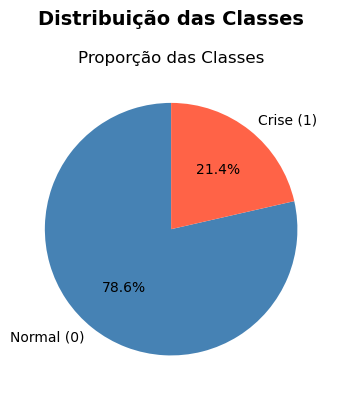

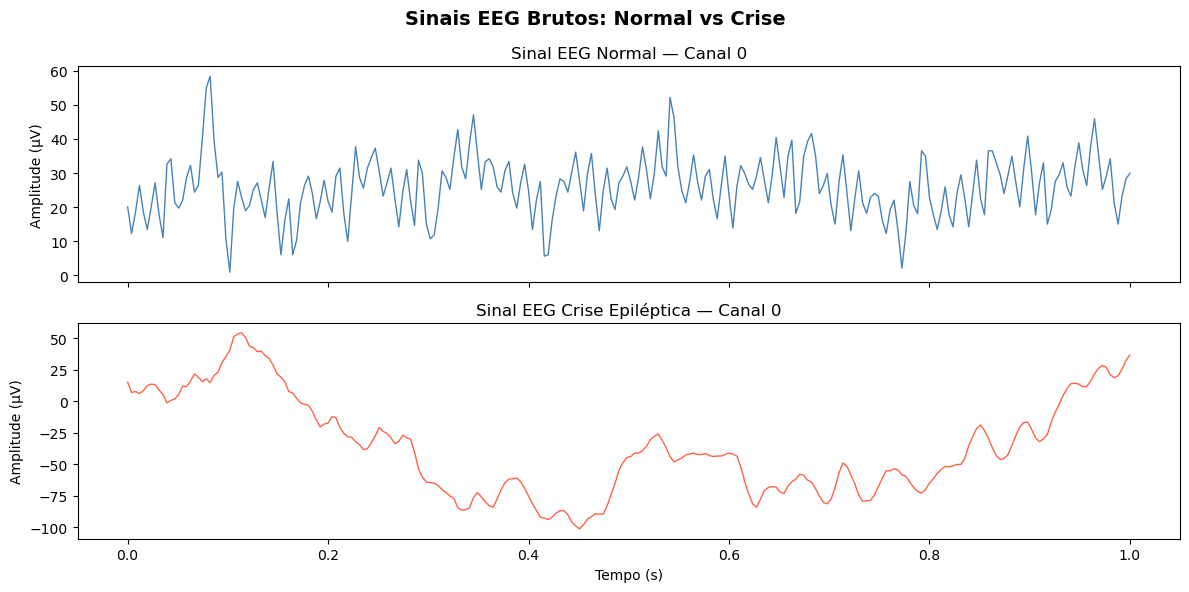

In [5]:
n_crise  = int((y == 1).sum()) # total de segmentos com crise
n_normal = int((y == 0).sum()) # total de segmentos normais
total    = len(y)
print(f'Classe 1 (Crise) : {n_crise} amostras ({100*n_crise/total:.1f}%)')
print(f'Classe 0 (Normal): {n_normal} amostras ({100*n_normal/total:.1f}%)')

# ── Gráfico de distribuição das classes ──────────────────────
# Gráfico de pizza para melhor visualização da distribuição dos dados
fig, ax = plt.subplots(figsize=(11, 4))
ax.pie([n_normal, n_crise], labels=['Normal (0)', 'Crise (1)'],
            autopct='%1.1f%%', colors=['steelblue', 'tomato'], startangle=90)
ax.set_title('Proporção das Classes')
plt.suptitle('Distribuição das Classes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Visualização dos sinais EEG brutos ───────────────────────
# Pega o primeiro índice de cada classe para comparação visual
idx_normal = np.where(y == 0)[0][0]
idx_crise  = np.where(y == 1)[0][0]

# Eixo de tempo: 256 pontos em 1 segundo = frequência de amostragem 256 Hz
t = np.linspace(0, 1, X.shape[2])
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(t, X[idx_normal, 0, :], color='steelblue', linewidth=1)
axes[0].set_title('Sinal EEG Normal — Canal 0')
axes[0].set_ylabel('Amplitude (μV)')
axes[1].plot(t, X[idx_crise,  0, :], color='tomato',    linewidth=1)
axes[1].set_title('Sinal EEG Crise Epiléptica — Canal 0')
axes[1].set_ylabel('Amplitude (μV)')
axes[1].set_xlabel('Tempo (s)')
plt.suptitle('Sinais EEG Brutos: Normal vs Crise', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.2 Balanceamento das Classes

O dataset tem **78% Normal vs 22% Crise**. Sem balancear, o modelo pode atingir
~78% de acurácia simplesmente prevendo sempre 'Normal'. Aplicamos **undersampling**
para igualar as classes na proporção 1:1.

In [6]:
idx1  = np.where(y == 1)[0]   # índices das amostras de crise
idx0  = np.where(y == 0)[0]   # índices das amostras normais
n_min = min(len(idx1), len(idx0))  # tamanho da menor classe

# Sorteia aleatoriamente n_min amostras de cada classe (sem reposição)
idx_bal = np.concatenate([
    np.random.choice(idx1, n_min, replace=False),
    np.random.choice(idx0, n_min, replace=False)
])

# Embaralha para evitar que o modelo veja padrões na ordem dos dados
np.random.shuffle(idx_bal)

X = X[idx_bal]
y = y[idx_bal]

## 5. Pré-processamento
### 5.1 Garantir que `y` fique em vetor
### 5.2 Transformar cada sinal em um vetor 1D (`flatten`)
### 5.3 Dividir em treino e teste
### 5.4 Normalizar com Z-score

#### Por que isso é importante?
Sem normalização, algumas variáveis podem ter escalas muito maiores do que outras, deformando a superfície da função objetivo e dificultando a convergência do método iterativo.

In [7]:
# Garantir que y fique em formato vetorial
y = y.reshape(-1)
print("Shape de y após reshape:", y.shape)

# Flatten: transforma cada amostra em vetor
X = X.reshape(X.shape[0], -1)
print("Shape de X após flatten:", X.shape)

# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nShapes após train_test_split:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

# Normalização
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("\nShapes após normalização:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

# Verificação de consistência
assert X_train.shape[0] == y_train.shape[0], "X_train e y_train têm tamanhos incompatíveis"
assert X_test.shape[0] == y_test.shape[0], "X_test e y_test têm tamanhos incompatíveis"

print("\nVerificação concluída: dimensões compatíveis.")

Shape de y após reshape: (16148,)
Shape de X após flatten: (16148, 5888)

Shapes após train_test_split:
X_train: (12918, 5888)
X_test : (3230, 5888)
y_train: (12918,)
y_test : (3230,)

Shapes após normalização:
X_train: (12918, 5888)
X_test : (3230, 5888)
y_train: (12918,)
y_test : (3230,)

Verificação concluída: dimensões compatíveis.


## 6. Formulação matemática

A regressão logística utiliza a função sigmoide:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

O modelo é definido como:

$$
\hat{y} = \sigma(Xw + b)
$$

A função de custo (Log-Loss) é dada por:

$$
J(w, b) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log(\hat{y}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)}) \right]
$$

A atualização dos parâmetros pelo gradiente descendente é:

$$
w \leftarrow w - \alpha \frac{\partial J}{\partial w}
$$

$$
b \leftarrow b - \alpha \frac{\partial J}{\partial b}
$$

## 7. Implementação da regressão logística do zero

In [8]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_cost(X, y, w, b):
    m = X.shape[0]
    z = X @ w + b
    y_hat = sigmoid(z)

    eps = 1e-10
    y_hat = np.clip(y_hat, eps, 1 - eps)

    cost = -(1 / m) * np.sum(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))
    return cost

def compute_gradients(X, y, w, b):
    m = X.shape[0]
    z = X @ w + b
    y_hat = sigmoid(z)

    dw = (1 / m) * (X.T @ (y_hat - y))
    db = (1 / m) * np.sum(y_hat - y)

    return dw, db

def gradient_descent(X, y, learning_rate=0.01, epochs=1000, verbose=True):
    n_features = X.shape[1]

    w = np.zeros(n_features)
    b = 0.0
    cost_history = []

    for epoch in range(epochs):
        dw, db = compute_gradients(X, y, w, b)

        w = w - learning_rate * dw
        b = b - learning_rate * db

        cost = compute_cost(X, y, w, b)
        cost_history.append(cost)

        if verbose and (epoch % 100 == 0 or epoch == epochs - 1):
            print(f"Época {epoch:4d} | custo = {cost:.6f}")

    return w, b, cost_history

def predict_proba(X, w, b):
    z = X @ w + b
    return sigmoid(z)

def predict(X, w, b, threshold=0.5):
    probs = predict_proba(X, w, b)
    return (probs >= threshold).astype(int)

## 8. Treinamento do modelo

Aqui vocês podem ajustar:
- `learning_rate`
- `epochs`

Se o custo estiver oscilando muito, geralmente a taxa de aprendizado está alta.  
Se estiver convergindo muito devagar, pode estar baixa demais.

In [9]:
learning_rate = 0.01
epochs = 1000

w, b, cost_history = gradient_descent(
    X_train,
    y_train,
    learning_rate=learning_rate,
    epochs=epochs,
    verbose=True
)

print("\nTreinamento concluído.")
print("Quantidade de valores em cost_history:", len(cost_history))

Época    0 | custo = 0.692135
Época  100 | custo = 0.663244
Época  200 | custo = 0.652231
Época  300 | custo = 0.644668
Época  400 | custo = 0.638734
Época  500 | custo = 0.633784
Época  600 | custo = 0.629506
Época  700 | custo = 0.625722
Época  800 | custo = 0.622319
Época  900 | custo = 0.619220
Época  999 | custo = 0.616397

Treinamento concluído.
Quantidade de valores em cost_history: 1000


## 9. Evolução da função objetivo

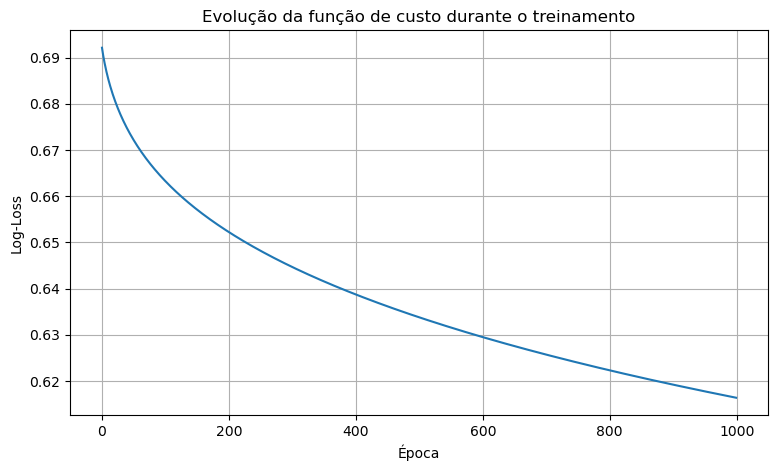

In [10]:
plt.figure(figsize=(9, 5))
plt.plot(cost_history)
plt.xlabel("Época")
plt.ylabel("Log-Loss")
plt.title("Evolução da função de custo durante o treinamento")
plt.grid(True)
plt.show()

## 10. Avaliação no conjunto de teste

In [11]:
y_pred = predict(X_test, w, b)
y_prob = predict_proba(X_test, w, b)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
cm = confusion_matrix(y_test, y_pred)

print("Resultados no conjunto de teste:")
print(f"Acurácia : {acc:.4f}")
print(f"Precisão : {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print("\nMatriz de confusão:")
print(cm)

Resultados no conjunto de teste:
Acurácia : 0.5526
Precisão : 0.5713
Recall   : 0.4217
F1-score : 0.4852

Matriz de confusão:
[[1104  511]
 [ 934  681]]


In [12]:
print("Relatório de classificação:\n")
print(classification_report(y_test, y_pred, digits=4))

Relatório de classificação:

              precision    recall  f1-score   support

           0     0.5417    0.6836    0.6044      1615
           1     0.5713    0.4217    0.4852      1615

    accuracy                         0.5526      3230
   macro avg     0.5565    0.5526    0.5448      3230
weighted avg     0.5565    0.5526    0.5448      3230



## 11. Visualização da matriz de confusão

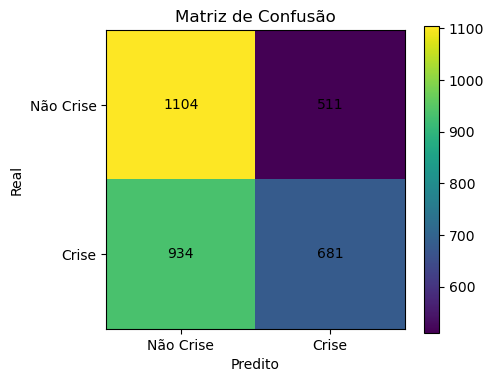

In [13]:
plt.figure(figsize=(5, 4))
plt.imshow(cm, interpolation="nearest")
plt.title("Matriz de Confusão")
plt.colorbar()
plt.xticks([0, 1], ["Não Crise", "Crise"])
plt.yticks([0, 1], ["Não Crise", "Crise"])
plt.xlabel("Predito")
plt.ylabel("Real")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.tight_layout()
plt.show()

## 12. Discussão dos resultados

Pontos que vocês podem comentar no relatório:

1. **A função de custo diminuiu ao longo das épocas?**  
   Se sim, isso indica que o Gradiente Descendente está convergindo.

2. **O modelo teve bom desempenho no teste?**  
   Avaliem acurácia, precisão, recall e F1-score.

3. **Houve equilíbrio entre detectar crises e evitar falsos alarmes?**  
   Isso pode ser observado na matriz de confusão.

4. **A normalização ajudou a estabilidade numérica?**  
   Em geral, sim — especialmente em problemas com muitas variáveis.

5. **A implementação manual ficou próxima da solução do `scikit-learn`?**  
   Se sim, isso fortalece a validade da modelagem.

## 13. Conclusão

Este projeto modelou a classificação de crises epilépticas por EEG como um problema de **otimização não linear sem restrições**.  
A Regressão Logística foi utilizada como classificador, e o treinamento foi conduzido por **Gradiente Descendente**, minimizando a função **Log-Loss**.

Do ponto de vista de ONL, o ponto central do trabalho é que:

- existe uma função objetivo não linear;
- seu gradiente pode ser calculado explicitamente;
- o problema pode ser resolvido por um método iterativo de primeira ordem;
- o desempenho final pode ser avaliado quantitativamente em dados de teste.

Assim, o notebook cumpre o objetivo de integrar:
- **modelagem matemática**,
- **otimização numérica**,
- **implementação computacional**,
- **análise de resultados**.

## 14. Referências básicas

- Sun, S.; Cao, Z.; Zhu, H.; Zhao, J. *A Survey of Optimization Methods From a Machine Learning Perspective*. IEEE Transactions on Cybernetics, 2019.
- Gambella, C.; Ghaddar, B.; Naoum-Sawaya, J. *Optimization Problems for Machine Learning: A Survey*. European Journal of Operational Research, 2021.
- Documentação do `scikit-learn`.
- Dataset CHB-MIT / EEG Seizure Analysis Dataset.